# Viral Cooking Trends on YouTube
## Time Series Analysis of Rise, Peak, and Decay Patterns

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
import os
os.chdir('..')  # move up from notebooks/ to project root
print(os.getcwd())  # confirm it shows your project root

c:\Users\glori\Documents\GlosResources\DE\Technische Hochschule Aschaffenburg\semester 3\Data Science Foundations of AI\feb-mar 2026 projects\data-science-portfolio\Time Series Analysis of Youtube Food Virality


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.visualize import TrendVisualizer
from src.features import FeatureEngineer
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
# Load data
daily_df = pd.read_csv('data/processed/daily_views_exponential.csv')
daily_df['date'] = pd.to_datetime(daily_df['date'])
peaks_df = pd.read_csv('data/processed/peak_analysis.csv')
peaks_df['peak_date'] = pd.to_datetime(peaks_df['peak_date'])
raw_df = pd.read_csv('data/raw/all_trends_complete.csv')
features_df = pd.read_csv('data/processed/trend_features.csv')

daily_df = daily_df.sort_values(['trend_name', 'date'])
daily_df['views_velocity'] = daily_df.groupby('trend_name')['views'].diff()

## 1. Overview: How Long Do Viral Trends Last?

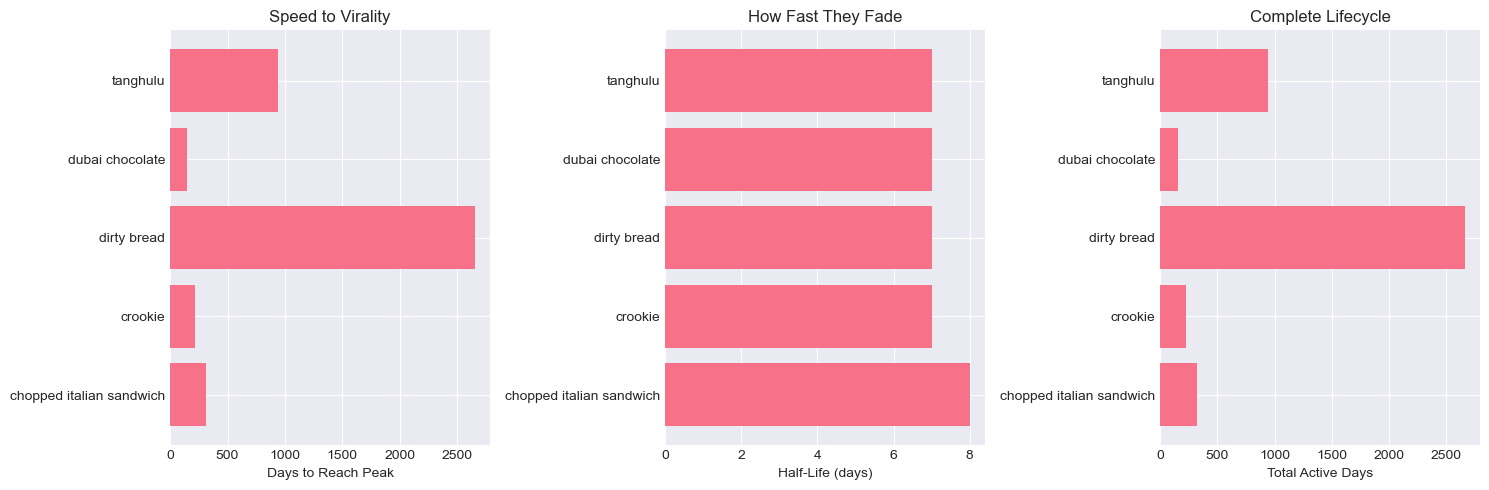

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Days to peak
axes[0].barh(features_df['trend_name'], features_df['days_to_peak'])
axes[0].set_xlabel('Days to Reach Peak')
axes[0].set_title('Speed to Virality')

# Half-life
axes[1].barh(features_df['trend_name'], features_df['half_life_days'])
axes[1].set_xlabel('Half-Life (days)')
axes[1].set_title('How Fast They Fade')

# Total lifespan
total_lifespan = features_df['days_to_peak'] + features_df['half_life_days'].fillna(60)
axes[2].barh(features_df['trend_name'], total_lifespan)
axes[2].set_xlabel('Total Active Days')
axes[2].set_title('Complete Lifecycle')

plt.tight_layout()
plt.savefig('data/figures/lifespan_summary.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. Trend Shape Classification

In [6]:
# Create shape summary
shape_summary = features_df.groupby('shape_classification').agg({
    'trend_name': 'count',
    'peak_intensity': 'mean',
    'days_to_peak': 'mean',
    'half_life_days': 'mean'
}).rename(columns={'trend_name': 'count'})

print("📊 Trend Shape Classification:")
print(shape_summary.to_string())

📊 Trend Shape Classification:
                      count  peak_intensity  days_to_peak  half_life_days
shape_classification                                                     
slow rise, fast fall      5       57.546638         855.2             7.2


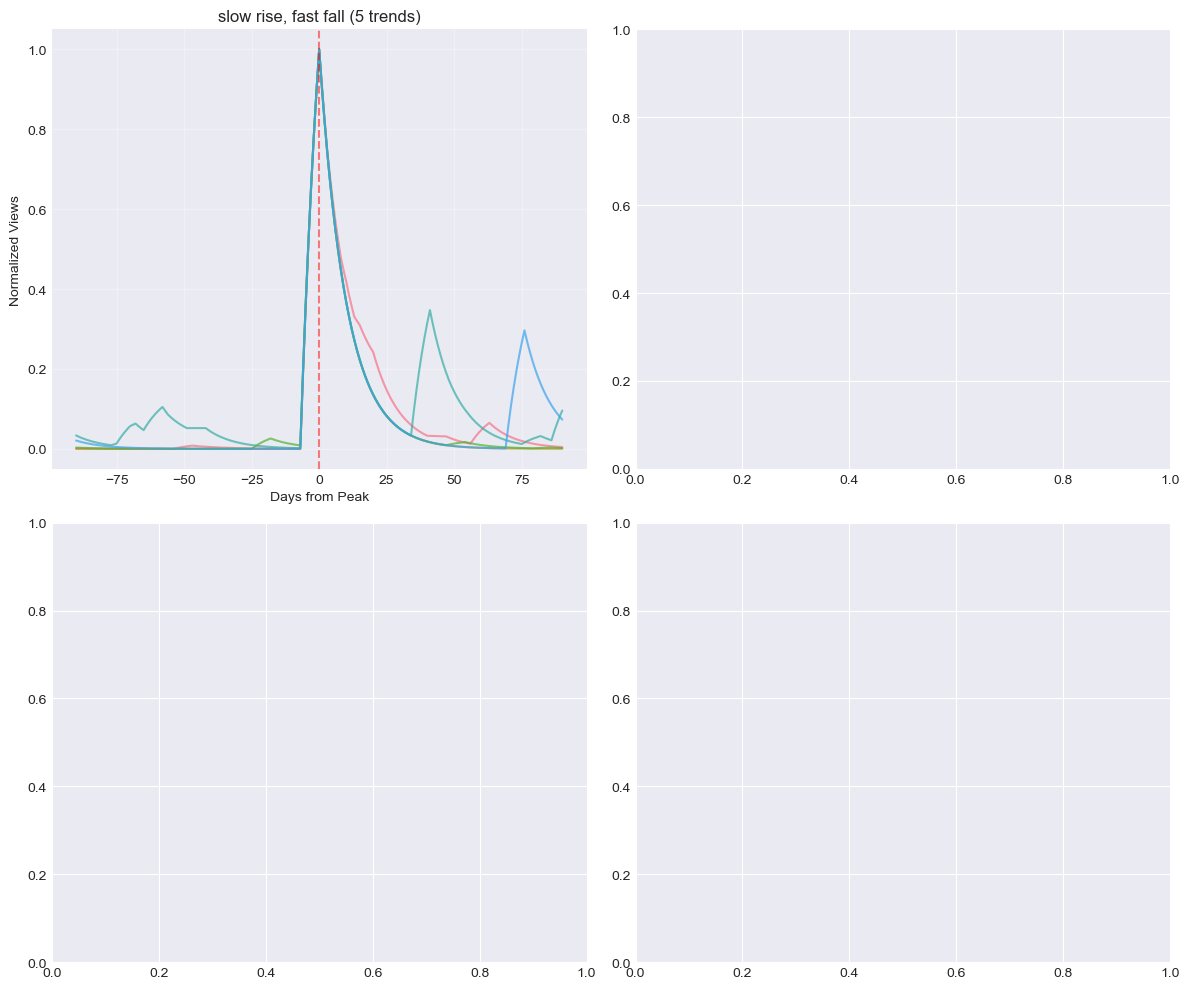

In [7]:
# Plot shapes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

shapes = features_df['shape_classification'].unique()
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']

for idx, shape in enumerate(shapes):
    trends_in_shape = features_df[features_df['shape_classification'] == shape]['trend_name'].values
    
    ax = axes[idx // 2, idx % 2]
    
    for trend in trends_in_shape:
        trend_data = daily_df[daily_df['trend_name'] == trend].copy()
        peak = trend_data['views_smooth_7d'].max()
        if peak > 0:
            trend_data['normalized'] = trend_data['views_smooth_7d'] / peak
            trend_data['days_from_peak'] = (trend_data['date'] - 
                                           pd.to_datetime(peaks_df[peaks_df['trend_name'] == trend]['peak_date'].values[0])).dt.days
            plot_data = trend_data[abs(trend_data['days_from_peak']) <= 90]
            ax.plot(plot_data['days_from_peak'], plot_data['normalized'], 
                   alpha=0.7, linewidth=1.5)
    
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f"{shape} ({len(trends_in_shape)} trends)")
    ax.set_xlabel('Days from Peak')
    ax.set_ylabel('Normalized Views')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/figures/shape_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. What Makes a Trend Go Viral? (Tag Analysis)

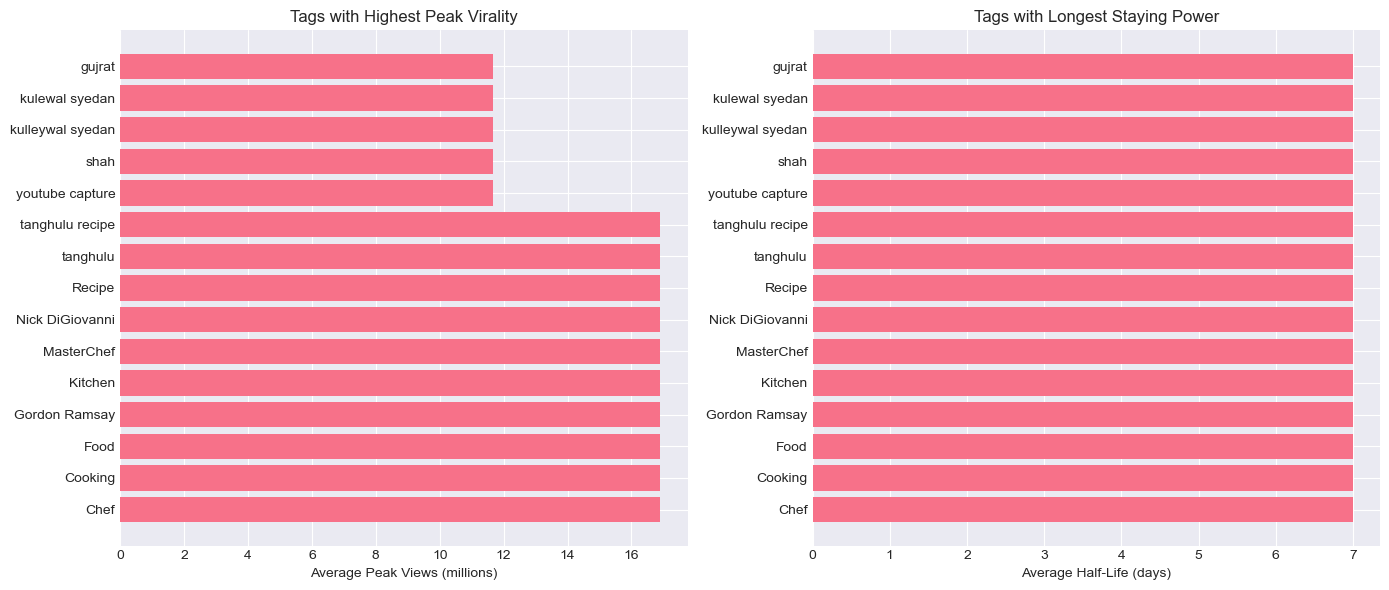


🏷️ Most Powerful Tags:
                  peak_views  half_life
tag                                    
Chef              16907248.4        7.0
Cooking           16907248.4        7.0
Food              16907248.4        7.0
Gordon Ramsay     16907248.4        7.0
Kitchen           16907248.4        7.0
MasterChef        16907248.4        7.0
Nick DiGiovanni   16907248.4        7.0
Recipe            16907248.4        7.0
tanghulu          16907248.4        7.0
tanghulu recipe   16907248.4        7.0
youtube capture   11655424.1        7.0
shah              11655424.1        7.0
kulleywal syedan  11655424.1        7.0
kulewal syedan    11655424.1        7.0
gujrat            11655424.1        7.0


In [8]:
tag_df = pd.read_csv('data/processed/tag_impact.csv')

# Top 15 most impactful tags
top_tags = tag_df.groupby('tag').agg({
    'peak_views': 'mean',
    'half_life': 'mean',
    'frequency': 'sum'
}).sort_values('peak_views', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Peak views by tag
axes[0].barh(range(len(top_tags)), top_tags['peak_views'].values / 1e6)
axes[0].set_yticks(range(len(top_tags)))
axes[0].set_yticklabels(top_tags.index)
axes[0].set_xlabel('Average Peak Views (millions)')
axes[0].set_title('Tags with Highest Peak Virality')

# Half-life by tag
axes[1].barh(range(len(top_tags)), top_tags['half_life'].values)
axes[1].set_yticks(range(len(top_tags)))
axes[1].set_yticklabels(top_tags.index)
axes[1].set_xlabel('Average Half-Life (days)')
axes[1].set_title('Tags with Longest Staying Power')

plt.tight_layout()
plt.savefig('data/figures/tag_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🏷️ Most Powerful Tags:")
print(top_tags[['peak_views', 'half_life']].round(1).to_string())

## 4. Engagement Analysis

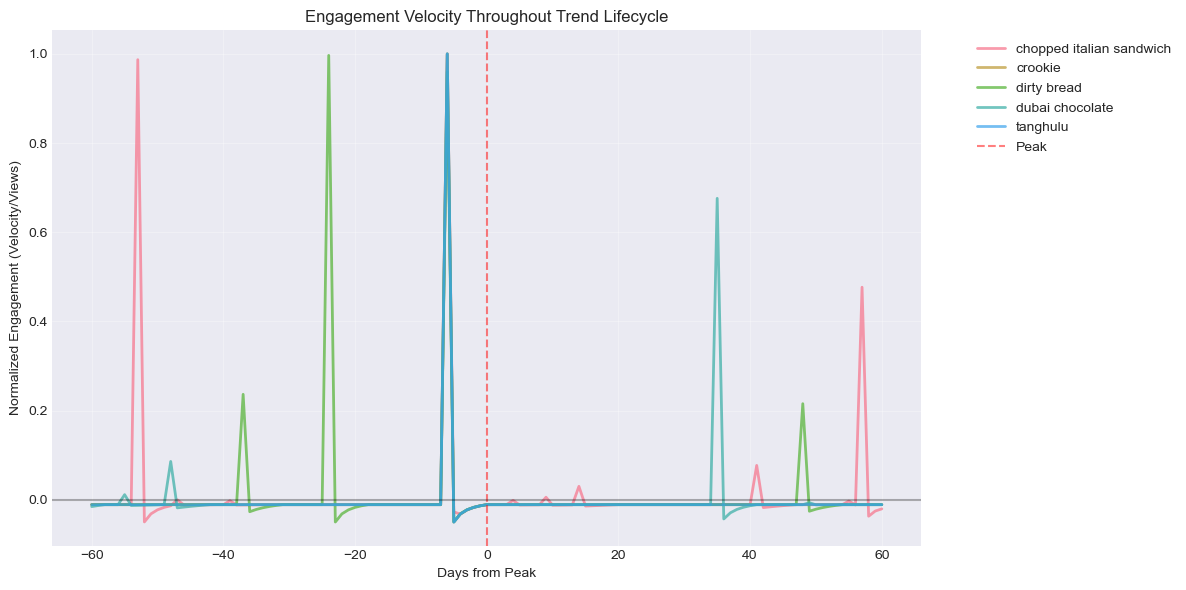

In [9]:
# Calculate engagement metrics
daily_with_velocity = daily_df.copy()
daily_with_velocity['engagement_views_ratio'] = daily_df['views_velocity'] / daily_df['views_smooth_7d']
daily_with_velocity['engagement_views_ratio'] = daily_with_velocity['engagement_views_ratio'].replace([np.inf, -np.inf], np.nan)

# Plot engagement over lifecycle
fig, ax = plt.subplots(figsize=(12, 6))

for trend in daily_with_velocity['trend_name'].unique():
    trend_data = daily_with_velocity[daily_with_velocity['trend_name'] == trend].copy()
    peak_date = peaks_df[peaks_df['trend_name'] == trend]['peak_date'].values[0]
    trend_data['days_from_peak'] = (trend_data['date'] - pd.to_datetime(peak_date)).dt.days
    
    # Normalize engagement for comparison
    engagement_clean = trend_data['engagement_views_ratio'].dropna()
    if len(engagement_clean) > 0:
        trend_data.loc[engagement_clean.index, 'engagement_norm'] = (
            engagement_clean / engagement_clean.abs().max()
        )
        
        plot_data = trend_data[abs(trend_data['days_from_peak']) <= 60]
        ax.plot(plot_data['days_from_peak'], plot_data['engagement_norm'], 
               alpha=0.7, linewidth=2, label=trend)

ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Peak')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Days from Peak')
ax.set_ylabel('Normalized Engagement (Velocity/Views)')
ax.set_title('Engagement Velocity Throughout Trend Lifecycle')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/figures/engagement_lifecycle.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Key Findings & Conclusions

In [10]:
# Summary statistics
print("="*60)
print("📈 VIRAL COOKING TRENDS: KEY FINDINGS")
print("="*60)

# Fastest rise
fastest_rise = features_df.loc[features_df['days_to_peak'].idxmin()]
print(f"\n⚡ Fastest to Peak: {fastest_rise['trend_name']}")
print(f"   - Reached peak in {fastest_rise['days_to_peak']:.0f} days")
print(f"   - Peak intensity: {fastest_rise['peak_intensity']:.1f}x average")

# Longest lasting
longest_half = features_df.loc[features_df['half_life_days'].idxmax()]
print(f"\n🐢 Longest Lasting: {longest_half['trend_name']}")
print(f"   - Half-life: {longest_half['half_life_days']:.0f} days")
print(f"   - Total days active: {longest_half['days_to_peak'] + longest_half['half_life_days']:.0f}")

# Most intense
most_intense = features_df.loc[features_df['peak_intensity'].idxmax()]
print(f"\n🔥 Most Intense Peak: {most_intense['trend_name']}")
print(f"   - Peak was {most_intense['peak_intensity']:.1f}x average daily views")
print(f"   - Total views: {most_intense['total_views']/1e6:.1f}M")

# Most engaging
most_engaging = features_df.loc[features_df['engagement_rate'].idxmax()]
print(f"\n❤️ Most Engaging: {most_engaging['trend_name']}")
print(f"   - Engagement rate: {most_engaging['engagement_rate']:.4f}")
print(f"   - Avg likes/video: {most_engaining['avg_likes_per_video']:.0f}")

# Pattern summary
print(f"\n📊 Pattern Distribution:")
for shape in features_df['shape_classification'].value_counts().index:
    count = features_df['shape_classification'].value_counts()[shape]
    pct = count / len(features_df) * 100
    print(f"   - {shape}: {count} trends ({pct:.0f}%)")

# Save final report
with open('reports/final_analysis.md', 'w') as f:
    f.write("# Viral Cooking Trends Analysis\n\n")
    f.write("## Key Metrics\n\n")
    f.write(f"- **Trends Analyzed:** {len(features_df)}\n")
    f.write(f"- **Total Videos:** {len(raw_df)}\n")
    f.write(f"- **Date Range:** {daily_df['date'].min().date()} to {daily_df['date'].max().date()}\n\n")
    
    f.write("## Top Findings\n\n")
    f.write(f"1. **Fastest to Peak:** {fastest_rise['trend_name']} ({fastest_rise['days_to_peak']} days)\n")
    f.write(f"2. **Longest Lasting:** {longest_half['trend_name']} ({longest_half['half_life_days']} days half-life)\n")
    f.write(f"3. **Most Intense:** {most_intense['trend_name']}\n\n")
    
    f.write("## Recommendations\n\n")
    f.write("- For quick virality, focus on tags that drive rapid growth\n")
    f.write("- For sustained trends, emphasize community-building content\n")
    f.write("- Peak engagement happens BEFORE peak views—strike while interest is high\n")

print("\n✅ Analysis complete! Check 'reports/final_analysis.md' for summary")

📈 VIRAL COOKING TRENDS: KEY FINDINGS

⚡ Fastest to Peak: dubai chocolate
   - Reached peak in 150 days
   - Peak intensity: 9.4x average

🐢 Longest Lasting: chopped italian sandwich
   - Half-life: 8 days
   - Total days active: 321

🔥 Most Intense Peak: dirty bread
   - Peak was 152.1x average daily views
   - Total views: 240.2M

❤️ Most Engaging: crookie
   - Engagement rate: 1.7694


NameError: name 'most_engaining' is not defined